北京市新冠肺炎确诊数预测

下表是 2020 年 1 月 20 日起 19 天的北京市新冠肺炎**累计确诊数**，请预测未来 10 天的确诊人数。

| 天数 | 1    | 2    | 3    | 4    | 5    | 6    | 7    | 8    | 9    | 10   | 11   | 12   | 13   | 14   | 15   | 16   | 17   | 18   | 19   |
| ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- |
| 人数 | 14   | 22   | 36   | 41   | 68   | 80   | 91   | 111  | 114  | 139  | 168  | 191  | 212  | 228  | 253  | 274  | 297  | 315  | 326  |



In [42]:
# 北京市新冠肺炎累计确诊数（2020.1.20 起，共 19 天）
days = list(range(1, 20))
cases = [14, 22, 36, 41, 68, 80, 91, 111, 114, 139,
         168, 191, 212, 228, 253, 274, 297, 315, 326]

print(f"天数: {days}")
print(f"累计确诊: {cases}")


天数: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
累计确诊: [14, 22, 36, 41, 68, 80, 91, 111, 114, 139, 168, 191, 212, 228, 253, 274, 297, 315, 326]


In [43]:
from scipy.optimize import curve_fit
def f(x, k, b):
    return k*x+b
res = curve_fit(f=f, xdata=days, ydata=cases)
print(res)


(array([ 18.37017544, -26.85964912]), array([[ 0.2357502 , -2.35750194],
       [-2.35750194, 30.64752469]]))


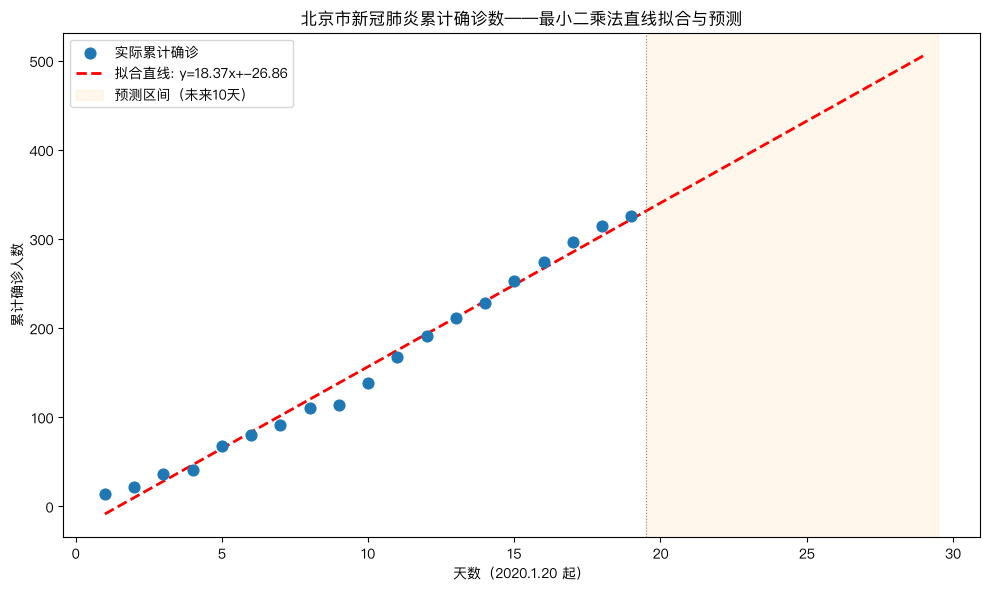

未来 10 天预测（累计确诊）：
  第 20 天: 341
  第 21 天: 359
  第 22 天: 377
  第 23 天: 396
  第 24 天: 414
  第 25 天: 432
  第 26 天: 451
  第 27 天: 469
  第 28 天: 488
  第 29 天: 506


In [44]:
import matplotlib.pyplot as plt

# 字体设置(适配中文) — macOS 优先使用苹方/黑体，Windows/Linux 回退
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 可视化拟合结果 ====================
k_fit, b_fit = res[0]  # curve_fit 返回 (最优参数, 协方差矩阵)

# 预测未来 10 天
days_future = list(range(1, 30))          # 1~29 天
cases_fit = [f(d, k_fit, b_fit) for d in days_future]

plt.figure(figsize=(10, 6))

# 原始数据
plt.scatter(days, cases, c='#1f77b4', s=60, zorder=3, label='实际累计确诊')

# 拟合曲线（含预测部分）
plt.plot(days_future, cases_fit, 'r--', linewidth=2, label=f'拟合直线: y={k_fit:.2f}x+{b_fit:.2f}')

# 预测区域标记
plt.axvspan(19.5, 29.5, alpha=0.08, color='orange', label='预测区间（未来10天）')
plt.axvline(x=19.5, color='gray', linewidth=0.8, linestyle=':')

plt.xlabel('天数（2020.1.20 起）')
plt.ylabel('累计确诊人数')
plt.title('北京市新冠肺炎累计确诊数——最小二乘法直线拟合与预测')
plt.legend()
plt.tight_layout()
plt.show()

# 打印预测值
print("未来 10 天预测（累计确诊）：")
for d in range(20, 30):
    pred = f(d, k_fit, b_fit)
    print(f"  第 {d:2d} 天: {pred:.0f}")



| 段号 | 时间 (mm:ss) | 平均速度 (公里/时) |
|:---:|:---:|:---:|
| 1 | 06:24 | 9.3 |
| 2 | 06:14 | 9.6 |
| 3 | 04:59 | 12.0 |
| 4 | 05:20 | 11.2 |
| 5 | 05:46 | 10.4 |
| 6 | 06:56 | 8.6 |
| 7 | 07:14 | 8.2 |
| 8 | 02:59 | 9.0 |


In [45]:
segments = [
    {"no": 1, "time": "06:24", "speed_kmh": 9.3},
    {"no": 2, "time": "06:14", "speed_kmh": 9.6},
    {"no": 3, "time": "04:59", "speed_kmh": 12.0},
    {"no": 4, "time": "05:20", "speed_kmh": 11.2},
    {"no": 5, "time": "05:46", "speed_kmh": 10.4},
    {"no": 6, "time": "06:56", "speed_kmh": 8.6},
    {"no": 7, "time": "07:14", "speed_kmh": 8.2},
    {"no": 8, "time": "02:59", "speed_kmh": 9.0},
]

x_time = [int(i["time"][0:2])*60+int(i["time"][3:5]) for i in segments]
for i in range(1, len(x_time)):
    x_time[i] += x_time[i-1]
y_speed = [float(i["speed_kmh"]) for i in segments]
print(x_time)
print(y_speed)

[384, 758, 1057, 1377, 1723, 2139, 2573, 2752]
[9.3, 9.6, 12.0, 11.2, 10.4, 8.6, 8.2, 9.0]


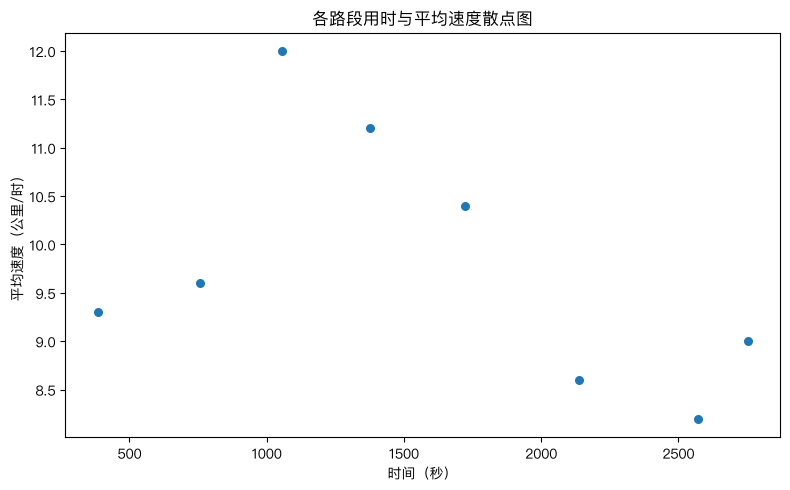

In [46]:
import matplotlib.pyplot as plt

# 字体设置(适配中文)
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 5))
plt.scatter(x_time, y_speed, c='#1f77b4', s=30, zorder=3)

plt.xlabel('时间（秒）')
plt.ylabel('平均速度（公里/时）')
plt.title('各路段用时与平均速度散点图')
plt.tight_layout()
plt.show()

In [47]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def f(x, k0, b0, k1, b1, a, b2, c):
    return np.where(
        x <= 1057,
        k0 * x + b0,
        np.where(
            x <= 2139,
            k1 * x + b1,
            a * x**2 + b2 * x + c
        )
    )

p0 = [0, 10, 0, 10, 0, 0, 10]
params, _ = curve_fit(f=f, xdata=x_time, ydata=y_speed, p0=p0)
k0, b0, k1, b1, a, b2, c = params


第1段 (x ≤ 1057):  y = 0.0039x + 7.46
第2段 (1057 < x ≤ 2139): y = -0.0034x + 16.08
第3段 (x > 2139): y = 0.000116x² + -0.6130x + 817.83


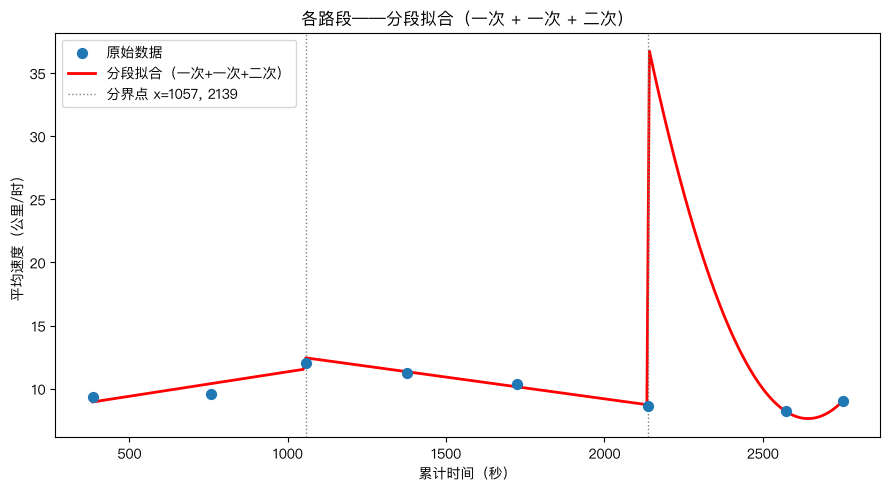

In [48]:

print(f"第1段 (x ≤ 1057):  y = {k0:.4f}x + {b0:.2f}")
print(f"第2段 (1057 < x ≤ 2139): y = {k1:.4f}x + {b1:.2f}")
print(f"第3段 (x > 2139): y = {a:.6f}x² + {b2:.4f}x + {c:.2f}")

# ——————— 可视化 ———————
x_smooth = np.linspace(min(x_time), max(x_time), 300)
y_fit = f(x_smooth, *params)

plt.figure(figsize=(9, 5))
plt.scatter(x_time, y_speed, c='#1f77b4', s=50, zorder=3, label='原始数据')
plt.plot(x_smooth, y_fit, 'r-', linewidth=2, label='分段拟合（一次+一次+二次）')
plt.axvline(x=1057, color='gray', linestyle=':', linewidth=1, label='分界点 x=1057, 2139')
plt.axvline(x=2139, color='gray', linestyle=':', linewidth=1)

plt.xlabel('累计时间（秒）')
plt.ylabel('平均速度（公里/时）')
plt.title('各路段——分段拟合（一次 + 一次 + 二次）')
plt.legend()
plt.tight_layout()
plt.show()